# Análisis profundo del dataset de elecciones

Este cuaderno documenta, depura y describe en detalle `elections_master_dpi.parquet`. El objetivo es producir una versión analítica, auditable y lista para investigación, con diagnóstico exhaustivo de cobertura, calidad y medición. Los resultados son estrictamente descriptivos y no implican causalidad.

## Definiciones clave

- **Evento electoral**: observación a nivel de elección con `event_id` único.
- **Clave estricta**: `iso3` + `office_type` + `election_date`. Se usa para detectar duplicados conceptuales.
- **`office_type`**: tipo de elección, típicamente `presidential` o `parliamentary`.
- **`share_metric`**: indica si `share_1` y `share_2` son votos o escaños (`vote_share` vs `seat_share`).
- **`date_precision`**: granularidad temporal reportada (`day`, `month`, `year`).
- **DPI pre/post**: variables políticas en el año previo y posterior a la elección.

## Consideraciones de medición

- `vote_share` y `seat_share` no son comparables sin normalización explícita.
- La precisión temporal (`date_precision`) es heterogénea y puede afectar análisis de ventanas cortas.
- Los flags institucionales suelen ser incompletos; se interpretan como indicadores mínimos.
- El matching de partidos e ideología no es perfecto y requiere cautela en inferencias finas.
- Las fuentes pueden diferir en cobertura y definiciones, especialmente en elecciones parlamentarias.

## Configuración y utilidades

Esta sección define rutas, estilo gráfico y funciones auxiliares para cargar datos y guardar tablas/figuras.


In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import yaml
import random
from IPython.display import display

pd.options.mode.copy_on_write = True

%matplotlib inline


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
}

NOTEBOOK_NAME = '01_elections_dataset_deep_dive_presentable'
OUT_ROOT = ROOT / 'outputs'
OUT_FIG = OUT_ROOT / 'figures' / NOTEBOOK_NAME
OUT_TAB = OUT_ROOT / 'tables' / NOTEBOOK_NAME
for p in [OUT_FIG, OUT_TAB]:
    p.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot style (clean, seminar-ready)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    table = pq.read_table(str(path))
    return table.to_pandas()


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, str(path))


def save_table(df: pd.DataFrame, name: str, *, index: bool = False, also_md: bool = False) -> None:
    write_parquet_pyarrow(df, OUT_TAB / f"{name}.parquet")
    df.to_csv(OUT_TAB / f"{name}.csv", index=index)
    if also_md:
        df_md = df.astype(object).where(pd.notna(df), None)
        (OUT_TAB / f"{name}.md").write_text(
            df_md.to_markdown(index=index, missingval="")
        )


def save_fig(name: str, fig=None) -> None:
    fig = fig or plt.gcf()
    fig.savefig(OUT_FIG / f"{name}.png", bbox_inches='tight')
    fig.savefig(OUT_FIG / f"{name}.pdf", bbox_inches='tight')


def assert_bounds(df: pd.DataFrame, col: str, lo: float, hi: float, tol: float = 1e-9, allow_na: bool = True) -> None:
    s = df[col]
    if not allow_na:
        s = s.dropna()
    bad = s[(s < lo - tol) | (s > hi + tol)]
    if not bad.empty:
        raise AssertionError(f"Column {col} has {len(bad)} values outside bounds [{lo},{hi}]")


def show_table(df: pd.DataFrame, title: str | None = None, n: int | None = None) -> None:
    if title:
        print(title)
    if n is None:
        display(df)
    else:
        display(df.head(n))


## Carga y normalización de claves

Se carga el dataset maestro y se normalizan campos clave (`iso3`, `election_year`, `election_month`). Se valida la unicidad de `event_id` antes de cualquier transformación.

In [2]:
# Load elections master
PATH_ELECTIONS = PATHS['data_processed'] / 'elections_master_dpi.parquet'
PATH_ELECTIONS_EFW2000 = PATHS['data_processed'] / 'elections_master_efw2000.parquet'

df = read_parquet_pyarrow(PATH_ELECTIONS)

# Normalize key columns
if 'iso3' in df.columns:
    df['iso3'] = df['iso3'].astype('string').str.upper().str.strip()
    df.loc[df['iso3'].isin(['', 'NAN', 'NONE', 'NULL']), 'iso3'] = pd.NA
if 'election_year' in df.columns:
    df['election_year'] = pd.to_numeric(df['election_year'], errors='coerce').astype('Int64')
if 'election_month' in df.columns:
    df['election_month'] = pd.to_numeric(df['election_month'], errors='coerce').astype('Int64')

print('elections_master shape:', df.shape)
print('event_id min/max:', df['event_id'].min(), df['event_id'].max())

assert df['event_id'].notna().all()
assert df['event_id'].is_unique


elections_master shape: (6503, 109)
event_id min/max: 0 6502


## Panorama general del dataset

Primero resumimos dimensiones, cobertura básica y métricas de missingness en variables críticas. Esto establece el mapa mental para el resto del análisis.

In [3]:
# Panorama general del dataset
overview = pd.DataFrame({
    'n_events': [int(len(df))],
    'n_countries': [int(df['iso3'].nunique(dropna=True)) if 'iso3' in df.columns else None],
    'n_sources': [int(df['source'].nunique(dropna=True)) if 'source' in df.columns else None],
    'n_office_types': [int(df['office_type'].nunique(dropna=True)) if 'office_type' in df.columns else None],
    'year_min': [int(df['election_year'].min()) if 'election_year' in df.columns and df['election_year'].notna().any() else None],
    'year_max': [int(df['election_year'].max()) if 'election_year' in df.columns and df['election_year'].notna().any() else None],
    'date_min': [df['election_date'].min() if 'election_date' in df.columns else None],
    'date_max': [df['election_date'].max() if 'election_date' in df.columns else None],
    'pct_missing_election_date': [float(df['election_date'].isna().mean()*100) if 'election_date' in df.columns else None],
    'pct_missing_share_1': [float(df['share_1'].isna().mean()*100) if 'share_1' in df.columns else None],
    'pct_missing_share_2': [float(df['share_2'].isna().mean()*100) if 'share_2' in df.columns else None],
    'pct_missing_margin': [float(df['margin'].isna().mean()*100) if 'margin' in df.columns else None],
})

save_table(overview, 'overview', also_md=True)
show_table(overview, title='Resumen del dataset')

# Muestra de columnas clave
key_cols = [c for c in ['event_id','iso3','country_name_raw','office_type','election_year','election_date','source','share_metric','margin'] if c in df.columns]
show_table(df[key_cols].head(8), title='Ejemplo de filas (columnas clave)')

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Uso de memoria aproximado: {mem_mb:.2f} MB")


Resumen del dataset


,n_events,n_countries,n_sources,n_office_types,year_min,year_max,date_min,date_max,pct_missing_election_date,pct_missing_share_1,pct_missing_share_2,pct_missing_margin
0,6503,219,3,2,1789,2024,1789-01-10,2024-06-01,5.382131,15.977241,25.6497,25.6497


Ejemplo de filas (columnas clave)


,event_id,iso3,country_name_raw,office_type,election_year,election_date,source,share_metric,margin
0,0,AFG,Afghanistan,presidential,2004,2004-10-09,ned_pres,vote_share,39.09
1,1,AFG,Afghanistan,presidential,2009,2009-08-20,ned_pres,vote_share,19.08
2,2,AFG,Afghanistan,presidential,2014,2014-06-14,ned_pres,vote_share,12.88
3,3,AFG,Afghanistan,presidential,2019,2019-09-28,ned_pres,vote_share,11.10
4,4,DZA,Algeria,presidential,1963,1963-09-15,ned_pres,vote_share,99.20
5,5,DZA,Algeria,presidential,1976,1976-12-10,ned_pres,vote_share,99.00
6,6,DZA,Algeria,presidential,1979,1979-02-07,ned_pres,vote_share,98.80
7,7,DZA,Algeria,presidential,1984,1984-01-12,ned_pres,vote_share,98.84


Uso de memoria aproximado: 16.71 MB


## Esquema y diccionario rápido

Se genera una tabla con nombres de columnas y tipos de dato. Esta tabla se guarda como artefacto auditable.

In [4]:
# Schema table
schema = pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str)})
save_table(schema, 'schema', also_md=True)
show_table(schema, title='Schema Table')


Schema Table


,column,dtype
source_election_id,source_election_id,float64
country_name_raw,country_name_raw,object
country_cow,country_cow,float64
date,date,datetime64[ns]
year,year,float64
...,...,...
dpi_execrlc_code_post1,dpi_execrlc_code_post1,Int64
dpi_gov1rlc_code_post1,dpi_gov1rlc_code_post1,Int64
dpi_gov2rlc_code_post1,dpi_gov2rlc_code_post1,Int64
dpi_gov3rlc_code_post1,dpi_gov3rlc_code_post1,Int64


## Cobertura temporal y estructura por tipo

En esta sección medimos densidad de eventos por año y década, y observamos cómo evoluciona la composición por `office_type`. Esto permite ubicar el dataset en el tiempo y detectar cambios de cobertura.

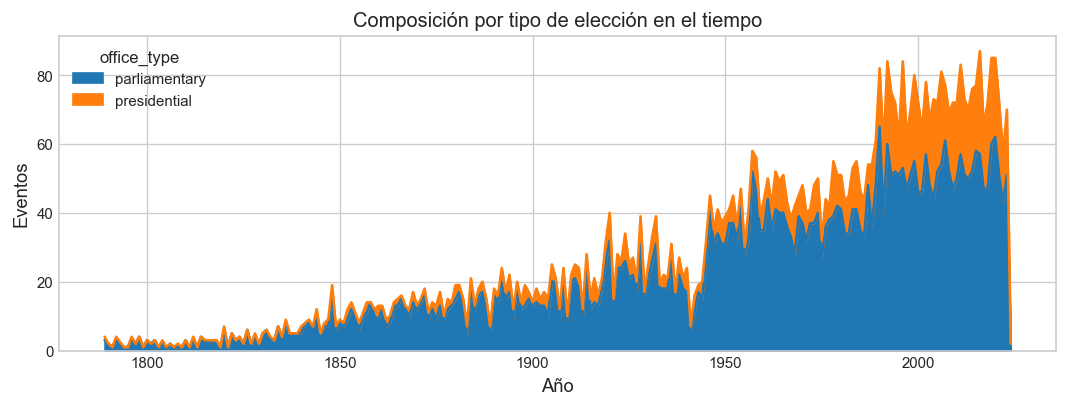

In [5]:
# Cobertura por año y década
cov_year = df.groupby('election_year', dropna=True).size().reset_index(name='n_events')
cov_year = cov_year.sort_values('election_year')
save_table(cov_year, 'coverage_by_year')

# Composición por tipo de elección
if {'election_year','office_type'}.issubset(df.columns):
    office_year = df.pivot_table(index='election_year', columns='office_type', values='event_id', aggfunc='count', fill_value=0)
    office_year = office_year.sort_index()
    office_year.to_csv(OUT_TAB / 'coverage_by_year_office_type.csv')

    office_year.plot.area(stacked=True, figsize=(9,3.5))
    plt.title('Composición por tipo de elección en el tiempo')
    plt.xlabel('Año')
    plt.ylabel('Eventos')
    plt.tight_layout()
    save_fig('coverage_by_year_office_type_area')
    plt.show()


## Cobertura geográfica y concentración

Analizamos la distribución por país (`iso3`) y el grado de concentración. Una cola larga puede implicar sesgos de disponibilidad que deben controlarse en análisis posteriores.

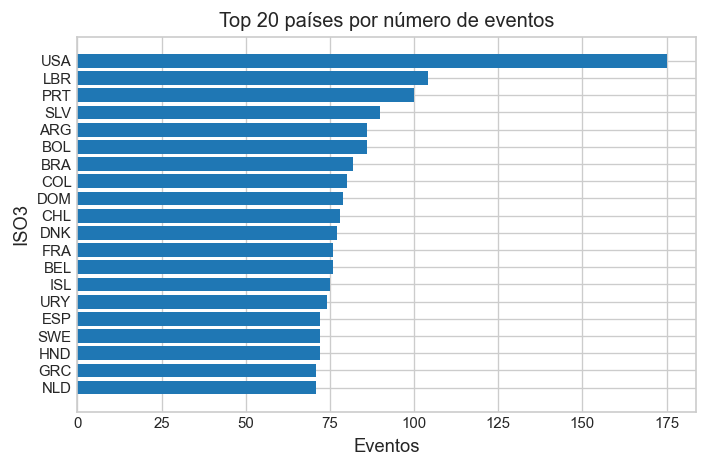

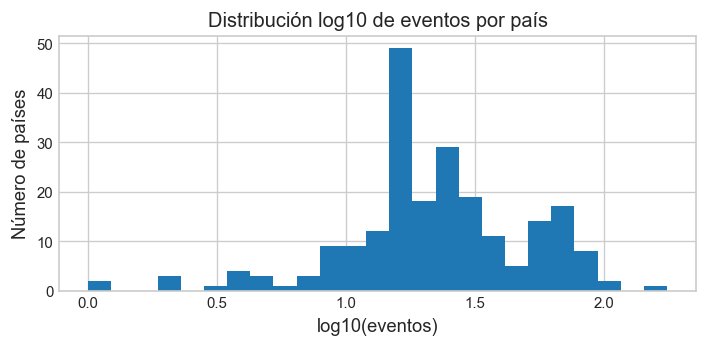

In [6]:
# Cobertura por país
cov_country = df['iso3'].fillna('MISSING_ISO3').value_counts().reset_index()
cov_country.columns = ['iso3','n_events']
cov_country['share'] = cov_country['n_events'] / len(df)
save_table(cov_country, 'coverage_by_country')

# Top 20 países
cov_top = cov_country.head(20).sort_values('n_events')
plt.figure(figsize=(6,4))
plt.barh(cov_top['iso3'], cov_top['n_events'])
plt.title('Top 20 países por número de eventos')
plt.xlabel('Eventos')
plt.ylabel('ISO3')
plt.tight_layout()
save_fig('coverage_by_country_top20')
plt.show()

# Distribución del número de eventos por país (cola larga)
counts = cov_country['n_events']
plt.figure(figsize=(6,3))
plt.hist(np.log10(counts), bins=25)
plt.title('Distribución log10 de eventos por país')
plt.xlabel('log10(eventos)')
plt.ylabel('Número de países')
plt.tight_layout()
save_fig('coverage_by_country_log_hist')
plt.show()


## Estacionalidad (mes de elección)

La distribución mensual ayuda a detectar patrones institucionales (calendarios electorales) y posibles errores de codificación cuando abundan meses faltantes.

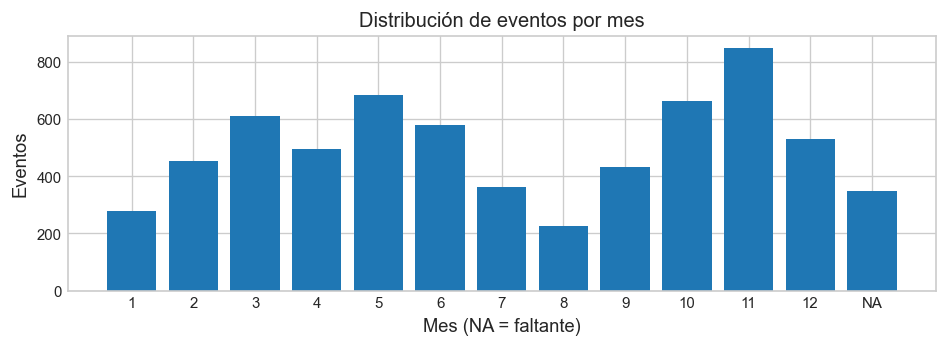

In [7]:
# Estacionalidad: mes de elección
if 'election_month' in df.columns:
    month_counts = df['election_month'].value_counts(dropna=False).reset_index()
    month_counts.columns = ['election_month','n_events']
    month_counts['month_label'] = month_counts['election_month'].astype('Int64').astype(str).replace('<NA>','NA')
    month_counts = month_counts.sort_values('election_month', na_position='last')
    save_table(month_counts, 'coverage_by_month')

    plt.figure(figsize=(8,3))
    plt.bar(month_counts['month_label'], month_counts['n_events'])
    plt.title('Distribución de eventos por mes')
    plt.xlabel('Mes (NA = faltante)')
    plt.ylabel('Eventos')
    plt.tight_layout()
    save_fig('coverage_by_month')
    plt.show()


## Fuentes y consistencia entre fuentes

Se documenta la participación relativa de cada fuente y su interacción con el tipo de elección. Esto es clave para comparabilidad y calidad homogénea.

Cobertura por fuente


,source,n_events,share
0,ned_parl,4900,0.753498
1,ned_pres,1409,0.216669
2,clea_lc,194,0.029832


Cobertura por tipo de elección


,office_type,n_events,share
0,parliamentary,5094,0.783331
1,presidential,1409,0.216669


Cobertura por share_metric


,share_metric,n_events,share
0,seat_share,4048,0.622482
1,vote_share,1426,0.219283
2,None,1029,0.158235


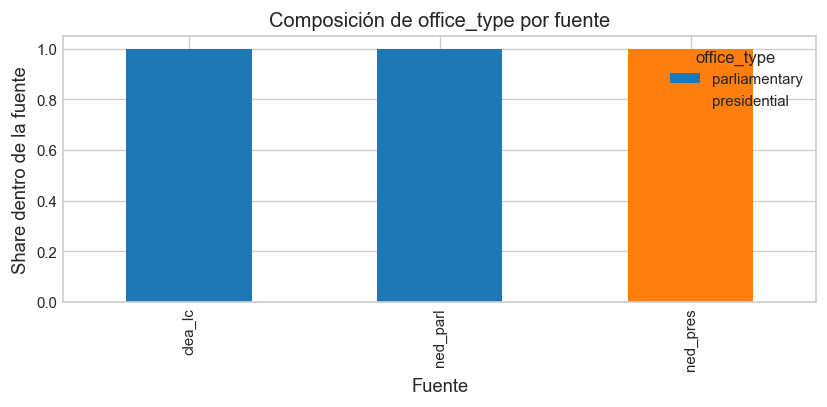

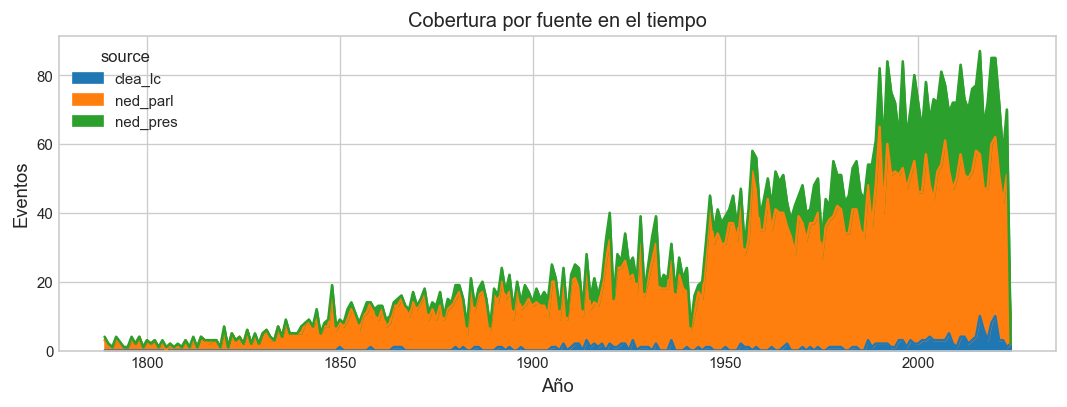

In [8]:
# Cobertura por fuente y consistencia con tipo de elección
coverage_source = df['source'].value_counts(dropna=False).rename_axis('source').reset_index(name='n_events')
coverage_source['share'] = coverage_source['n_events'] / len(df)
save_table(coverage_source, 'coverage_by_source', also_md=True)
show_table(coverage_source, title='Cobertura por fuente')

coverage_office = df['office_type'].value_counts(dropna=False).rename_axis('office_type').reset_index(name='n_events')
coverage_office['share'] = coverage_office['n_events'] / len(df)
save_table(coverage_office, 'coverage_by_office_type', also_md=True)
show_table(coverage_office, title='Cobertura por tipo de elección')

coverage_share_metric = df['share_metric'].value_counts(dropna=False).rename_axis('share_metric').reset_index(name='n_events')
coverage_share_metric['share'] = coverage_share_metric['n_events'] / len(df)
save_table(coverage_share_metric, 'coverage_by_share_metric', also_md=True)
show_table(coverage_share_metric, title='Cobertura por share_metric')

# Tabla cruzada fuente x office_type
if {'source','office_type'}.issubset(df.columns):
    source_office = pd.crosstab(df['source'], df['office_type'])
    save_table(source_office, 'coverage_source_by_office')

    source_office_share = source_office.div(source_office.sum(axis=1), axis=0).fillna(0)
    source_office_share.plot(kind='bar', stacked=True, figsize=(7,3.5))
    plt.title('Composición de office_type por fuente')
    plt.xlabel('Fuente')
    plt.ylabel('Share dentro de la fuente')
    plt.tight_layout()
    save_fig('coverage_source_by_office_share')
    plt.show()

# Serie temporal por fuente
if {'election_year','source'}.issubset(df.columns):
    source_year = df.pivot_table(index='election_year', columns='source', values='event_id', aggfunc='count', fill_value=0)
    source_year = source_year.sort_index()
    source_year.to_csv(OUT_TAB / 'coverage_by_year_source.csv')

    source_year.plot.area(stacked=True, figsize=(9,3.5))
    plt.title('Cobertura por fuente en el tiempo')
    plt.xlabel('Año')
    plt.ylabel('Eventos')
    plt.tight_layout()
    save_fig('coverage_by_year_source_area')
    plt.show()


DPI Core Missingness (pre/post)


,variable,missing_share,n_nonmissing
0,dpi_execrlc_code_pre1,0.667538,2162
1,dpi_execrlc_code_post1,0.670921,2140
2,dpi_polariz_pre1,0.706136,1911
3,dpi_polariz_post1,0.714132,1859


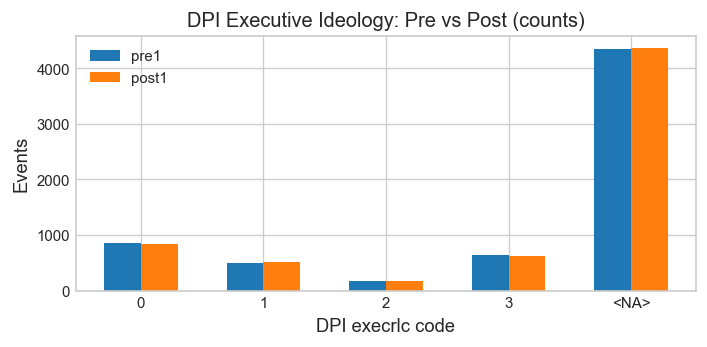

DPI Executive Ideology Transition (shares)


dpi_execrlc_code_post1,0,1,2,3,<NA>
dpi_execrlc_code_pre1,,,,,
0,0.1067,0.0072,0.0040,0.0043,0.0091
1,0.0052,0.0484,0.0049,0.0138,0.0042
2,0.0026,0.0054,0.0141,0.0032,0.0015
3,0.0078,0.0152,0.0032,0.0675,0.0038
<NA>,0.0057,0.0031,0.0009,0.0055,0.6523


Deltas pre/post (top 10)


,variable,n_nonmissing,mean_delta,p50_delta,p10_delta,p90_delta
0,dpi_year,6503,2.000000,2.000000,2.000000,2.000000
1,dpi_herfgov,1879,0.378570,0.000000,-0.256621,0.215028
4,dpi_govfrac,1879,0.011465,0.000000,-0.216340,0.264472
6,dpi_frac,1841,0.019529,0.000000,-0.115474,0.160634
7,dpi_polariz,1675,0.034030,0.000000,0.000000,0.000000
2,dpi_herfopp,1524,0.866515,0.000000,-0.281708,0.313019
5,dpi_oppfrac,1517,-0.006492,0.000000,-0.322419,0.294865
3,dpi_herftot,26,-0.020235,-0.000207,-0.084752,0.011286


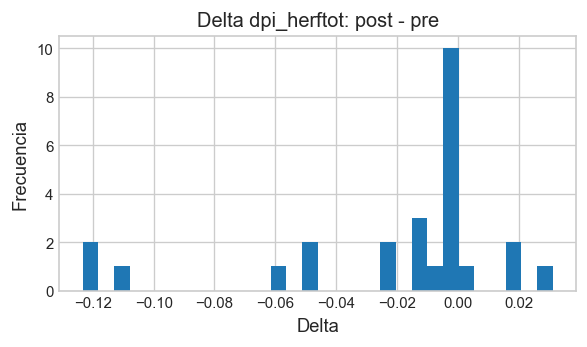

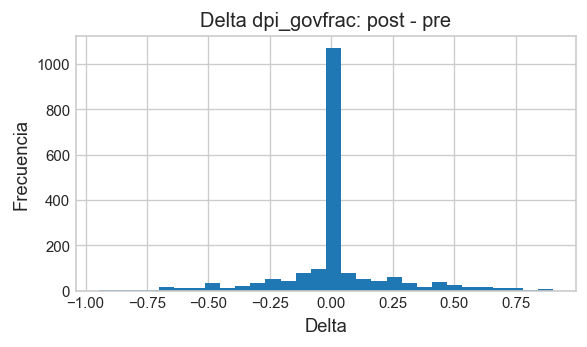

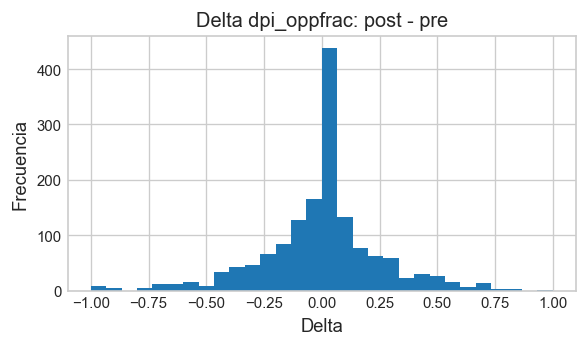

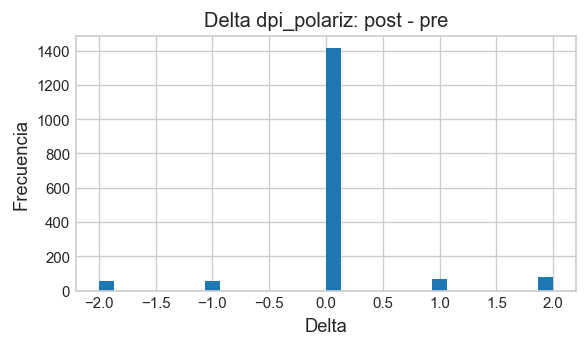

In [9]:
# DPI coverage and transitions (pre/post)

# Core DPI variables to track
core_dpi = [
    'dpi_execrlc_code_pre1', 'dpi_execrlc_code_post1',
    'dpi_polariz_pre1', 'dpi_polariz_post1'
]

existing_core = [c for c in core_dpi if c in df.columns]
if existing_core:
    dpi_cov = pd.DataFrame({
        'variable': existing_core,
        'missing_share': [df[c].isna().mean() for c in existing_core],
        'n_nonmissing': [df[c].notna().sum() for c in existing_core],
    }).sort_values('missing_share')
    save_table(dpi_cov, 'dpi_core_missingness', also_md=True)
    show_table(dpi_cov, title='DPI Core Missingness (pre/post)')

if {'dpi_execrlc_code_pre1','dpi_execrlc_code_post1'}.issubset(df.columns):
    dist_pre = df['dpi_execrlc_code_pre1'].value_counts(dropna=False).sort_index().rename('pre1')
    dist_post = df['dpi_execrlc_code_post1'].value_counts(dropna=False).sort_index().rename('post1')
    dist = pd.concat([dist_pre, dist_post], axis=1).fillna(0).reset_index().rename(columns={'index':'execrlc_code'})
    save_table(dist, 'dpi_execrlc_code_pre_post_dist', also_md=True)

    plt.figure(figsize=(6,3))
    x = np.arange(len(dist))
    plt.bar(x - 0.15, dist['pre1'], width=0.3, label='pre1')
    plt.bar(x + 0.15, dist['post1'], width=0.3, label='post1')
    plt.xticks(x, dist['execrlc_code'].astype(str))
    plt.xlabel('DPI execrlc code')
    plt.ylabel('Events')
    plt.title('DPI Executive Ideology: Pre vs Post (counts)')
    plt.legend()
    plt.tight_layout()
    save_fig('dpi_execrlc_pre_post_dist')
    plt.show()

    # Transition matrix (pre -> post)
    trans = pd.crosstab(df['dpi_execrlc_code_pre1'], df['dpi_execrlc_code_post1'], dropna=False)
    trans_share = (trans / trans.values.sum()).round(4)
    save_table(trans, 'dpi_execrlc_transition_counts')
    save_table(trans_share, 'dpi_execrlc_transition_shares')
    show_table(trans_share, title='DPI Executive Ideology Transition (shares)')


# Diferencias numéricas pre/post (solo variables numéricas no-categóricas)
pre_cols = [c for c in df.columns if c.startswith('dpi_') and c.endswith('_pre1')]
post_cols = [c for c in df.columns if c.startswith('dpi_') and c.endswith('_post1')]
pairs = []
for pre in pre_cols:
    post = pre.replace('_pre1','_post1')
    if post in df.columns:
        if ('_code_' in pre) or pre.endswith('_code_pre1'):
            continue
        if pd.api.types.is_numeric_dtype(df[pre]) and pd.api.types.is_numeric_dtype(df[post]):
            pairs.append((pre, post))

rows = []
for pre, post in pairs:
    delta = df[post] - df[pre]
    rows.append({
        'variable': pre.replace('_pre1',''),
        'n_nonmissing': int(delta.notna().sum()),
        'mean_delta': float(delta.mean()) if delta.notna().any() else None,
        'p50_delta': float(delta.median()) if delta.notna().any() else None,
        'p10_delta': float(delta.quantile(0.1)) if delta.notna().any() else None,
        'p90_delta': float(delta.quantile(0.9)) if delta.notna().any() else None,
    })

if rows:
    dpi_delta = pd.DataFrame(rows).sort_values('n_nonmissing', ascending=False)
    save_table(dpi_delta, 'dpi_pre_post_deltas', also_md=True)
    show_table(dpi_delta.head(10), title='Deltas pre/post (top 10)')

# Ejemplo de distribución de delta para variables clave
for base in ['dpi_herftot','dpi_govfrac','dpi_oppfrac','dpi_polariz']:
    pre = f'{base}_pre1'
    post = f'{base}_post1'
    if {pre, post}.issubset(df.columns) and pd.api.types.is_numeric_dtype(df[pre]):
        delta = (df[post] - df[pre]).dropna()
        if not delta.empty:
            plt.figure(figsize=(5,3))
            plt.hist(delta, bins=30)
            plt.title(f'Delta {base}: post - pre')
            plt.xlabel('Delta')
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            save_fig(f'dpi_delta_{base}')
            plt.show()


## DPI: Distribución pre vs post (rlc)

Comparaciones para `dpi_gov1rlc`, `dpi_execrlc` y `dpi_opp1rlc`. Si la variable es categórica, se usan barras y matrices de transición; si es numérica, se reportan estadísticas, histogramas, boxplots, dispersión y deltas.


DPI rlc missingness: pre vs post


,variable,share_pre_nonmissing,share_post_nonmissing,share_both_nonmissing
0,dpi_gov1rlc,0.312471,0.319237,0.291250
1,dpi_execrlc,0.332462,0.329079,0.313855
2,dpi_opp1rlc,0.258650,0.269260,0.235584


DPI dpi_gov1rlc: distribución categorial pre vs post


,category,pre1,post1,pre_share,post_share
0,NA,4471,4427,0.687529,0.680763
1,0,664,699,0.102107,0.107489
2,Left,662,652,0.101799,0.100261
3,Right,516,543,0.079348,0.083500
4,Center,190,182,0.029217,0.027987


<Figure size 780x384 with 0 Axes>

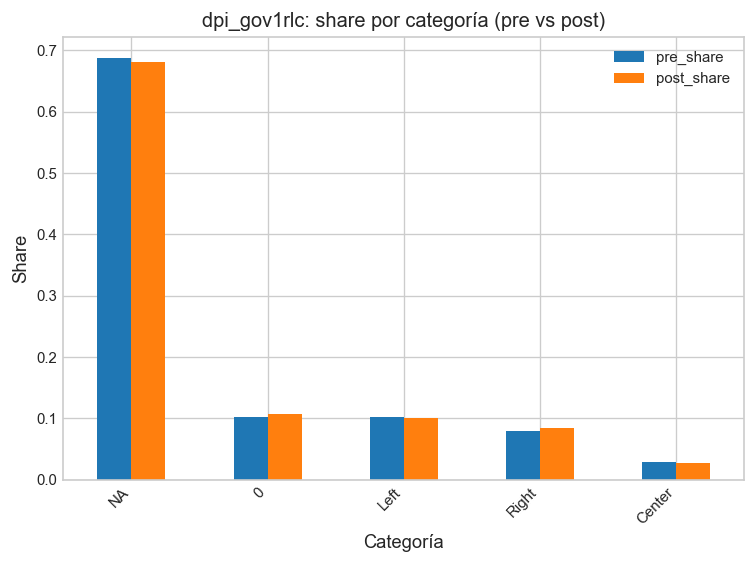

dpi_gov1rlc: transición pre -> post (shares)


dpi_gov1rlc_post1,0,Center,Left,NA,Right
dpi_gov1rlc_pre1,,,,,
0,0.0806,0.0040,0.0035,0.0091,0.0049
Center,0.0026,0.0152,0.0029,0.0025,0.0060
Left,0.0080,0.0037,0.0690,0.0048,0.0163
NA,0.0117,0.0018,0.0097,0.6595,0.0048
Right,0.0046,0.0032,0.0151,0.0049,0.0515


DPI dpi_execrlc: distribución categorial pre vs post


,category,pre1,post1,pre_share,post_share
0,NA,4341,4363,0.667538,0.670921
1,0,854,833,0.131324,0.128095
2,Left,635,614,0.097647,0.094418
3,Right,498,516,0.076580,0.079348
4,Center,175,177,0.026911,0.027218


<Figure size 780x384 with 0 Axes>

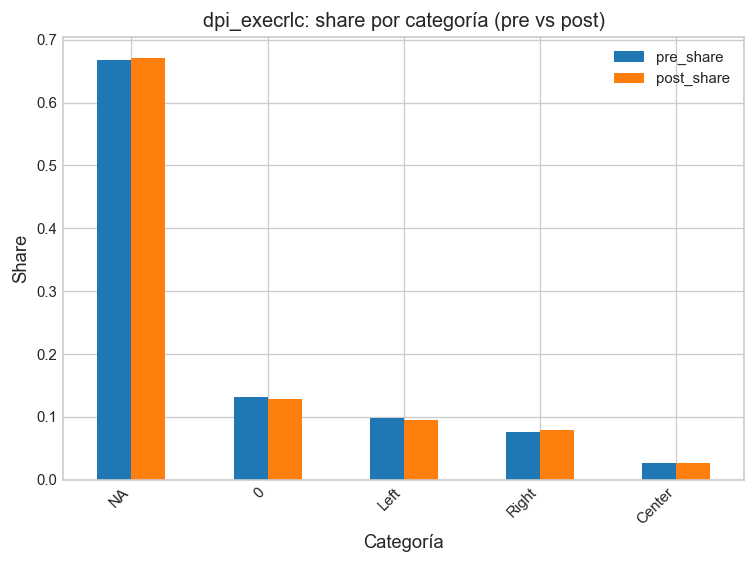

dpi_execrlc: transición pre -> post (shares)


dpi_execrlc_post1,0,Center,Left,NA,Right
dpi_execrlc_pre1,,,,,
0,0.1067,0.0040,0.0043,0.0091,0.0072
Center,0.0026,0.0141,0.0032,0.0015,0.0054
Left,0.0078,0.0032,0.0675,0.0038,0.0152
NA,0.0057,0.0009,0.0055,0.6523,0.0031
Right,0.0052,0.0049,0.0138,0.0042,0.0484


DPI dpi_opp1rlc: distribución categorial pre vs post


,category,pre1,post1,pre_share,post_share
0,NA,4821,4752,0.741350,0.730740
1,0,570,609,0.087652,0.093649
2,Left,512,522,0.078733,0.080271
3,Right,464,474,0.071352,0.072889
4,Center,136,146,0.020913,0.022451


<Figure size 780x384 with 0 Axes>

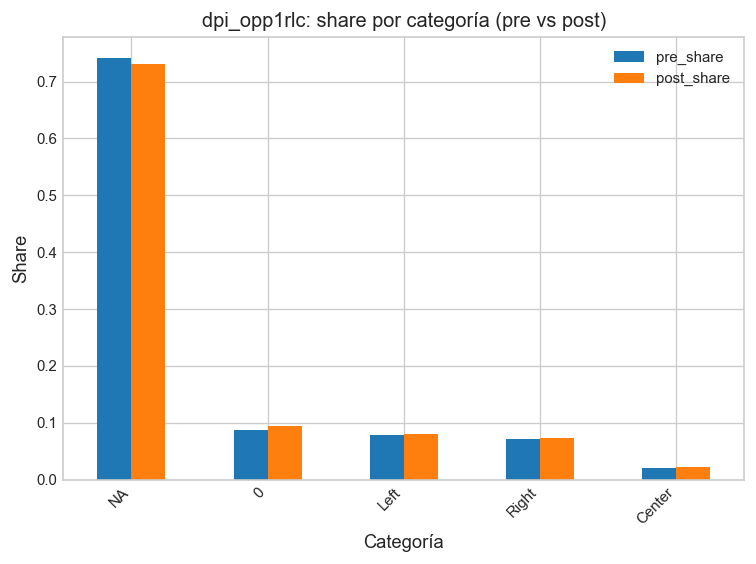

dpi_opp1rlc: transición pre -> post (shares)


dpi_opp1rlc_post1,0,Center,Left,NA,Right
dpi_opp1rlc_pre1,,,,,
0,0.0586,0.0025,0.0088,0.0125,0.0054
Center,0.0029,0.0094,0.0040,0.0017,0.0029
Left,0.0095,0.0031,0.0418,0.0063,0.0180
NA,0.0151,0.0032,0.0074,0.7077,0.0080
Right,0.0075,0.0043,0.0183,0.0026,0.0386


In [10]:
# DPI rlc pre vs post: análisis comparativo (maneja variables categóricas)
rlc_vars = ['dpi_gov1rlc', 'dpi_execrlc', 'dpi_opp1rlc']
pairs = [(f'{v}_pre1', f'{v}_post1') for v in rlc_vars]
pairs = [(pre, post) for pre, post in pairs if {pre, post}.issubset(df.columns)]

def _clean_missing(s: pd.Series) -> pd.Series:
    return s.replace({-999: pd.NA, '-999': pd.NA})

def _is_numeric_like(s: pd.Series) -> bool:
    if pd.api.types.is_numeric_dtype(s):
        return True
    s = s.dropna()
    if s.empty:
        return True
    s_str = s.astype(str)
    numeric_mask = s_str.str.fullmatch(r"[-+]?\d+(\.\d+)?")
    return bool(numeric_mask.all())

def _clean_cat(s: pd.Series) -> pd.Series:
    return _clean_missing(s).fillna('NA').astype(str)

if pairs:
    # Missingness comparativa (tratando -999 como missing)
    miss_rows = []
    for pre, post in pairs:
        pre_c = _clean_missing(df[pre])
        post_c = _clean_missing(df[post])
        miss_rows.append({
            'variable': pre.replace('_pre1',''),
            'share_pre_nonmissing': float(pre_c.notna().mean()),
            'share_post_nonmissing': float(post_c.notna().mean()),
            'share_both_nonmissing': float((pre_c.notna() & post_c.notna()).mean()),
        })
    miss_tab = pd.DataFrame(miss_rows)
    save_table(miss_tab, 'dpi_rlc_missingness', also_md=True)
    show_table(miss_tab, title='DPI rlc missingness: pre vs post')

    # Estadísticos (numéricos) y análisis categorial
    stats_rows = []
    delta_rows = []
    corr_rows = []

    for pre, post in pairs:
        var = pre.replace('_pre1','')
        pre_c = _clean_missing(df[pre])
        post_c = _clean_missing(df[post])
        is_numeric = _is_numeric_like(pre_c) and _is_numeric_like(post_c)

        if is_numeric:
            pre_s = pd.to_numeric(pre_c, errors='coerce').dropna()
            post_s = pd.to_numeric(post_c, errors='coerce').dropna()

            for label, s in [('pre', pre_s), ('post', post_s)]:
                stats_rows.append({
                    'variable': var,
                    'period': label,
                    'n': int(s.shape[0]),
                    'mean': float(s.mean()) if len(s) else None,
                    'p10': float(s.quantile(0.10)) if len(s) else None,
                    'median': float(s.median()) if len(s) else None,
                    'p90': float(s.quantile(0.90)) if len(s) else None,
                    'std': float(s.std()) if len(s) else None,
                })

            delta = (pd.to_numeric(post_c, errors='coerce') - pd.to_numeric(pre_c, errors='coerce')).dropna()
            if not delta.empty:
                delta_rows.append({
                    'variable': var,
                    'n': int(delta.shape[0]),
                    'mean_delta': float(delta.mean()),
                    'median_delta': float(delta.median()),
                    'p10_delta': float(delta.quantile(0.10)),
                    'p90_delta': float(delta.quantile(0.90)),
                    'std_delta': float(delta.std()),
                    'share_pos_delta': float((delta > 0).mean()),
                    'share_neg_delta': float((delta < 0).mean()),
                    'share_zero_delta': float((delta == 0).mean()),
                })
            sub = pd.DataFrame({pre: pd.to_numeric(pre_c, errors='coerce'), post: pd.to_numeric(post_c, errors='coerce')}).dropna()
            if not sub.empty:
                corr = float(sub[pre].corr(sub[post]))
                corr_rows.append({
                    'variable': var,
                    'n_pairs': int(len(sub)),
                    'corr_pre_post': corr,
                })

            # Gráficos numéricos
            combined = pd.concat([pre_s, post_s], ignore_index=True)
            if not combined.empty:
                lo, hi = float(combined.min()), float(combined.max())
                bins = np.linspace(lo, hi, 31) if lo != hi else 30
                plt.figure(figsize=(6,3))
                plt.hist(pre_s, bins=bins, alpha=0.6, label='pre1')
                plt.hist(post_s, bins=bins, alpha=0.6, label='post1')
                plt.title(f'Distribución {var}: pre vs post')
                plt.xlabel(var)
                plt.ylabel('Frecuencia')
                plt.legend()
                plt.tight_layout()
                save_fig(f'dpi_{var}_pre_post_hist')
                plt.show()

            plt.figure(figsize=(4.5,3))
            plt.boxplot([pre_s, post_s], labels=['pre1','post1'])
            plt.title(f'Boxplot {var}: pre vs post')
            plt.ylabel(var)
            plt.tight_layout()
            save_fig(f'dpi_{var}_pre_post_boxplot')
            plt.show()

            sub = pd.DataFrame({pre: pd.to_numeric(pre_c, errors='coerce'), post: pd.to_numeric(post_c, errors='coerce')}).dropna()
            if not sub.empty:
                lo = float(sub.min().min())
                hi = float(sub.max().max())
                plt.figure(figsize=(4.5,4))
                plt.scatter(sub[pre], sub[post], s=10, alpha=0.4)
                plt.plot([lo, hi], [lo, hi], 'r--', lw=1)
                corr = sub[pre].corr(sub[post])
                plt.title(f'{var}: pre vs post (corr={corr:.2f})')
                plt.xlabel('pre1')
                plt.ylabel('post1')
                plt.tight_layout()
                save_fig(f'dpi_{var}_pre_post_scatter')
                plt.show()

            delta = (pd.to_numeric(post_c, errors='coerce') - pd.to_numeric(pre_c, errors='coerce')).dropna()
            if not delta.empty:
                plt.figure(figsize=(6,3))
                plt.hist(delta, bins=30)
                plt.title(f'Delta {var}: post - pre')
                plt.xlabel('Delta')
                plt.ylabel('Frecuencia')
                plt.tight_layout()
                save_fig(f'dpi_{var}_delta_hist')
                plt.show()

        else:
            # Categorial: distribución y transición pre/post
            pre_cat = _clean_cat(df[pre])
            post_cat = _clean_cat(df[post])

            dist_pre = pre_cat.value_counts(dropna=False).rename('pre1')
            dist_post = post_cat.value_counts(dropna=False).rename('post1')
            dist = pd.concat([dist_pre, dist_post], axis=1).fillna(0)
            dist['pre_share'] = dist['pre1'] / dist['pre1'].sum()
            dist['post_share'] = dist['post1'] / dist['post1'].sum()
            dist = dist.sort_values('pre1', ascending=False)

            save_table(dist.reset_index().rename(columns={'index':'category'}), f'dpi_{var}_pre_post_dist', also_md=True)
            show_table(dist.reset_index().rename(columns={'index':'category'}), title=f'DPI {var}: distribución categorial pre vs post')

            # Bar chart (shares)
            plt.figure(figsize=(6.5,3.2))
            dist[['pre_share','post_share']].plot(kind='bar')
            plt.title(f'{var}: share por categoría (pre vs post)')
            plt.xlabel('Categoría')
            plt.ylabel('Share')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            save_fig(f'dpi_{var}_pre_post_bar')
            plt.show()

            # Matriz de transición
            trans = pd.crosstab(pre_cat, post_cat, dropna=False)
            trans_share = (trans / trans.values.sum()).round(4)
            save_table(trans, f'dpi_{var}_transition_counts')
            save_table(trans_share, f'dpi_{var}_transition_shares')
            show_table(trans_share, title=f'{var}: transición pre -> post (shares)')

    # Tablas numéricas (si hay)
    if stats_rows:
        stats_tab = pd.DataFrame(stats_rows)
        save_table(stats_tab, 'dpi_rlc_pre_post_stats', also_md=True)
        show_table(stats_tab, title='DPI rlc: estadísticos pre vs post (solo numéricos)')

    if delta_rows:
        delta_tab = pd.DataFrame(delta_rows)
        save_table(delta_tab, 'dpi_rlc_delta_stats', also_md=True)
        show_table(delta_tab, title='DPI rlc: estadísticas de delta (solo numéricos)')

    if corr_rows:
        corr_tab = pd.DataFrame(corr_rows)
        save_table(corr_tab, 'dpi_rlc_pre_post_corr', also_md=True)
        show_table(corr_tab, title='DPI rlc: correlación pre vs post (solo numéricos)')


## Precisión de fechas

La precisión temporal afecta inferencias de corto plazo. Esta sección mide la distribución de `date_precision` y su evolución en el tiempo.

Date Precision Distribution


,date_precision,n_events,share
0,day,5959,0.916346
1,year,349,0.053668
2,month,195,0.029986


Pct Missing election_date by Precision


,date_precision,pct_missing_election_date
0,day,0.000000
1,month,0.512821
2,year,100.000000


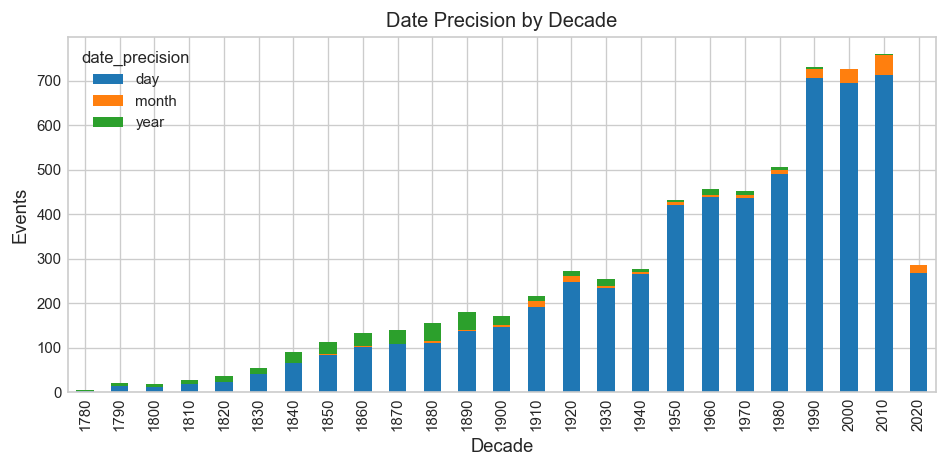

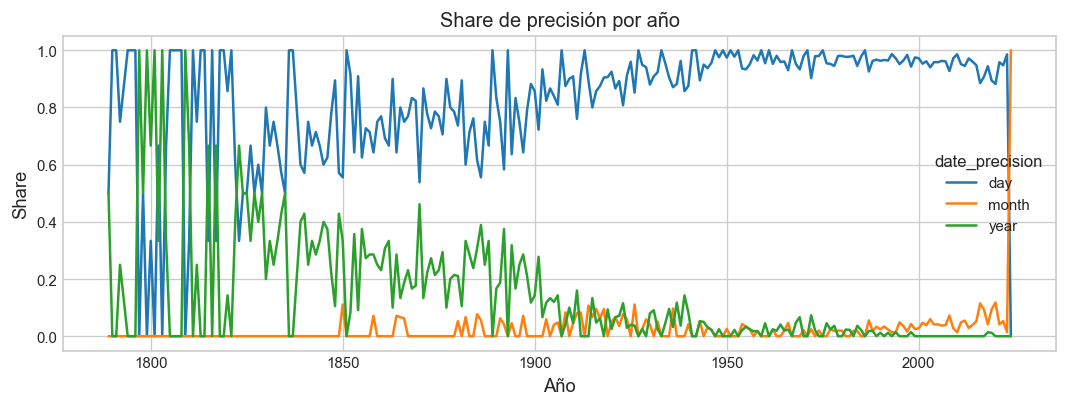

In [11]:
# Date precision audit
precision = df['date_precision'].value_counts(dropna=False).reset_index()
precision.columns = ['date_precision','n_events']
precision['share'] = precision['n_events'] / len(df)
save_table(precision, 'date_precision', also_md=True)
show_table(precision, title='Date Precision Distribution')

# Missingness of election_date by precision
prec_missing = df.groupby('date_precision')['election_date'].apply(lambda s: s.isna().mean()*100).reset_index(name='pct_missing_election_date')
save_table(prec_missing, 'date_precision_missing_election_date')
show_table(prec_missing, title='Pct Missing election_date by Precision')

# Plot stacked bar by decade
if 'election_year' in df.columns:
    df['decade'] = (df['election_year'].fillna(0).astype(int) // 10) * 10
    decade_tab = df.pivot_table(index='decade', columns='date_precision', values='event_id', aggfunc='count', fill_value=0)
    decade_tab.plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title('Date Precision by Decade')
    plt.xlabel('Decade')
    plt.ylabel('Events')
    plt.tight_layout()
    save_fig('date_precision_by_decade')
    plt.show()


# Precisión por año (share)
if {'election_year','date_precision'}.issubset(df.columns):
    prec_year = df.groupby(['election_year','date_precision']).size().reset_index(name='n_events')
    total_year = df.groupby('election_year').size().reset_index(name='total')
    prec_year = prec_year.merge(total_year, on='election_year', how='left')
    prec_year['share'] = prec_year['n_events'] / prec_year['total']
    prec_pivot = prec_year.pivot(index='election_year', columns='date_precision', values='share').fillna(0)
    prec_pivot.plot(figsize=(9,3.5))
    plt.title('Share de precisión por año')
    plt.xlabel('Año')
    plt.ylabel('Share')
    plt.tight_layout()
    save_fig('date_precision_share_by_year')
    plt.show()


## Shares y márgenes electorales

Se auditan `share_1`, `share_2` y `margin`, incluyendo consistencia interna, distribución, outliers y diferencias entre `vote_share` y `seat_share`.

margin mismatches: 0
Largest Margins (top 20)


,event_id,iso3,office_type,election_year,margin,flag_unopposed,flag_plebiscite,share_metric
165,165,CAF,presidential,1964,100.0,NaN,1.0,vote_share
1173,1173,SOM,presidential,1986,100.0,NaN,1.0,vote_share
1199,1199,SYR,presidential,1985,100.0,NaN,1.0,vote_share
1200,1200,SYR,presidential,1991,100.0,NaN,1.0,vote_share
1201,1201,SYR,presidential,1999,100.0,NaN,1.0,vote_share
395,395,EGY,presidential,1965,100.0,NaN,1.0,vote_share
211,211,COL,presidential,1949,100.0,1.0,NaN,vote_share
394,394,EGY,presidential,1958,100.0,NaN,1.0,vote_share
771,771,LBR,presidential,1959,100.0,NaN,NaN,vote_share
4334,4334,MSR,parliamentary,1978,100.0,NaN,NaN,seat_share


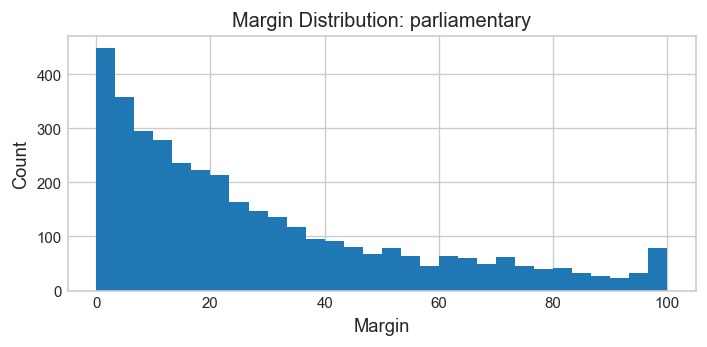

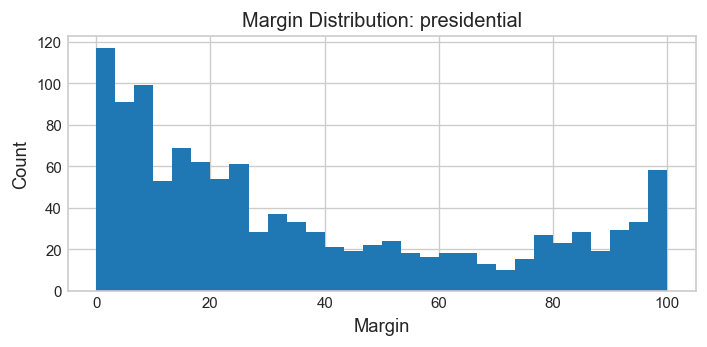

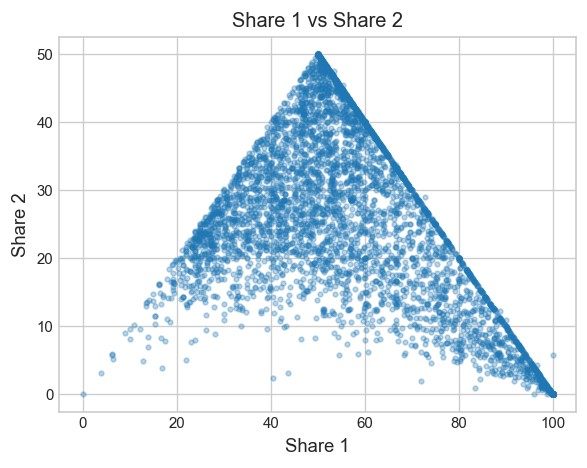

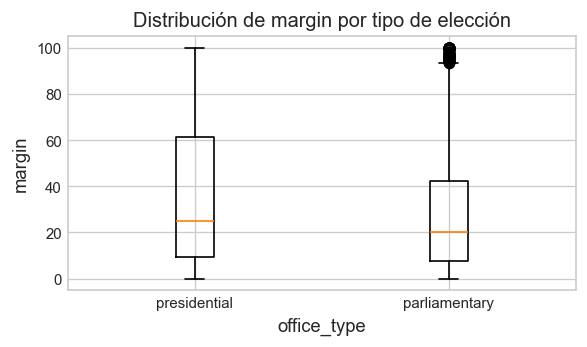

In [12]:
# Shares/margins audit
# Bounds checks (non-fatal; log warnings)
for col in ['share_1','share_2','margin']:
    if col in df.columns:
        try:
            assert_bounds(df, col, 0, 100, allow_na=True)
        except AssertionError as e:
            print('WARNING:', e)

# Check margin consistency where share_1/share_2 not missing
if {'share_1','share_2','margin'}.issubset(df.columns):
    tmp = df[['share_1','share_2','margin']].dropna()
    mismatch = (tmp['margin'] - (tmp['share_1'] - tmp['share_2'])).abs() > 1e-6
    print('margin mismatches:', int(mismatch.sum()))

# Largest margins table
largest_margin = df[['event_id','iso3','office_type','election_year','margin','flag_unopposed','flag_plebiscite','share_metric']].sort_values('margin', ascending=False).head(20)
save_table(largest_margin, 'largest_margins', also_md=True)
show_table(largest_margin, title='Largest Margins (top 20)')

# Histogram of margin by office_type
if 'margin' in df.columns:
    for office in ['parliamentary','presidential']:
        subset = df[df['office_type'] == office]
        plt.figure(figsize=(6,3))
        subset['margin'].dropna().hist(bins=30)
        plt.title(f'Margin Distribution: {office}')
        plt.xlabel('Margin')
        plt.ylabel('Count')
        plt.tight_layout()
        save_fig(f'margin_hist_{office}')
        plt.show()

# Share_1 vs share_2 scatter
if {'share_1','share_2'}.issubset(df.columns):
    plt.figure(figsize=(5,4))
    plt.scatter(df['share_1'], df['share_2'], alpha=0.3, s=8)
    plt.title('Share 1 vs Share 2')
    plt.xlabel('Share 1')
    plt.ylabel('Share 2')
    plt.tight_layout()
    save_fig('share1_vs_share2')
    plt.show()


# Margin por tipo de elección (boxplot)
if {'margin','office_type'}.issubset(df.columns):
    data = [df[df['office_type']==o]['margin'].dropna() for o in df['office_type'].dropna().unique()]
    labels = [o for o in df['office_type'].dropna().unique()]
    plt.figure(figsize=(5,3))
    plt.boxplot(data, labels=labels)
    plt.title('Distribución de margin por tipo de elección')
    plt.xlabel('office_type')
    plt.ylabel('margin')
    plt.tight_layout()
    save_fig('margin_by_office_box')
    plt.show()


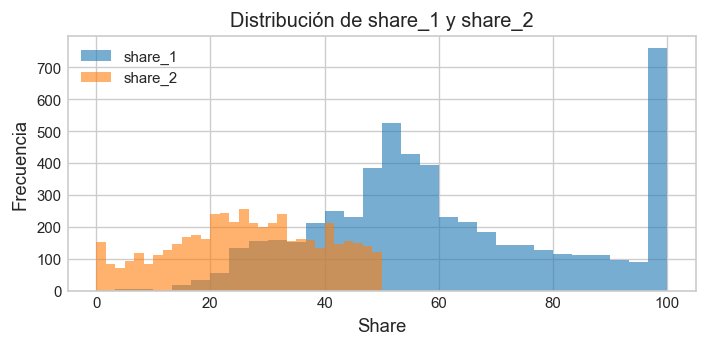

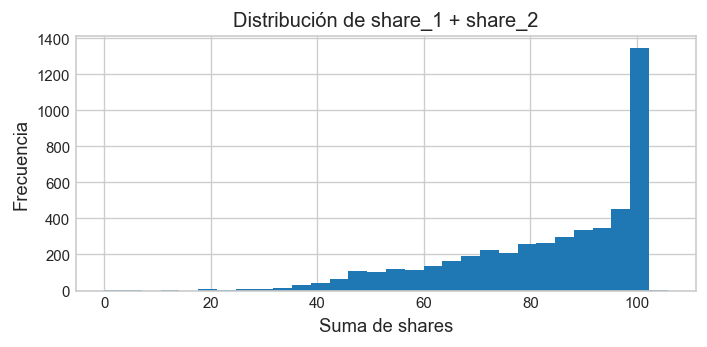

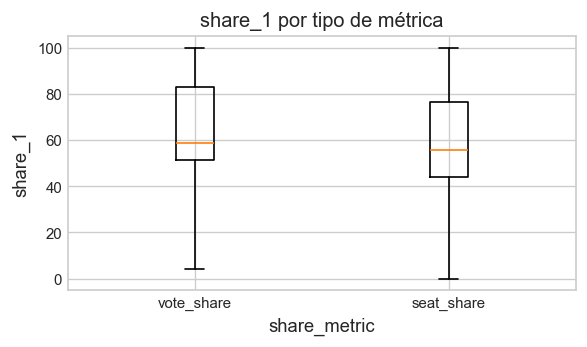

In [13]:
# Shares y consistencia adicional
for col in ['share_1','share_2','margin']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Distribución conjunta de shares
if {'share_1','share_2'}.issubset(df.columns):
    plt.figure(figsize=(6,3))
    plt.hist(df['share_1'].dropna(), bins=30, alpha=0.6, label='share_1')
    plt.hist(df['share_2'].dropna(), bins=30, alpha=0.6, label='share_2')
    plt.title('Distribución de share_1 y share_2')
    plt.xlabel('Share')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    save_fig('share1_share2_hist')
    plt.show()

# Suma share_1 + share_2
if {'share_1','share_2'}.issubset(df.columns):
    df['share_sum12'] = df['share_1'] + df['share_2']
    plt.figure(figsize=(6,3))
    plt.hist(df['share_sum12'].dropna(), bins=30)
    plt.title('Distribución de share_1 + share_2')
    plt.xlabel('Suma de shares')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    save_fig('share_sum12_hist')
    plt.show()

    outliers = df[df['share_sum12'] > 100][['event_id','iso3','office_type','election_year','share_sum12','share_metric']]
    save_table(outliers.sort_values('share_sum12', ascending=False).head(20), 'share_sum12_outliers_top20')

# Diferencias por métrica
if {'share_metric','share_1'}.issubset(df.columns):
    metrics = [m for m in df['share_metric'].dropna().unique()]
    data = [df[df['share_metric']==m]['share_1'].dropna() for m in metrics]
    if len(data) > 0:
        plt.figure(figsize=(5,3))
        plt.boxplot(data, labels=[str(m) for m in metrics])
        plt.title('share_1 por tipo de métrica')
        plt.xlabel('share_metric')
        plt.ylabel('share_1')
        plt.tight_layout()
        save_fig('share1_by_metric_box')
        plt.show()


## Matching de partidos

Se evalúa la calidad del matching de partidos para ganador y runner-up, incluyendo tasas de coincidencia exacta, fuzzy y casos ambiguos.

Winner Party Match Status


,winner_party_match_status,n_events,share
0,matched_exact,2863,0.440258
1,unmatched,1335,0.205290
2,missing,1050,0.161464
3,ambiguous_exact,612,0.094110
4,generic,360,0.055359
5,matched_fuzzy,155,0.023835
6,no_candidates,85,0.013071
7,ambiguous_fuzzy,29,0.004459
8,matched_fuzzy_tie,14,0.002153


Runner-up Party Match Status


,runnerup_party_match_status,n_events,share
0,matched_exact,2344,0.360449
1,missing,1770,0.272182
2,unmatched,1229,0.188990
3,ambiguous_exact,554,0.085191
4,generic,322,0.049516
5,matched_fuzzy,163,0.025065
6,no_candidates,74,0.011379
7,ambiguous_fuzzy,29,0.004459
8,matched_fuzzy_tie,18,0.002768


EFW Post-2000: Missing Winner Ideology (top 20)


,iso3,n_events_missing_winner_ideo
37,ECU,14
22,CHL,13
72,KWT,12
88,MNE,11
15,BLR,11
136,TWN,10
2,ARG,10
69,KGZ,10
77,LKA,9
9,BEN,9


Manual Override Backlog (top 20)


,iso3,n_events_backlog
25,CAN,40
6,AUS,32
111,NZL,23
66,IRL,21
115,PHL,18
163,ZWE,17
154,VCT,16
54,GMB,16
52,GIB,16
107,NGA,16


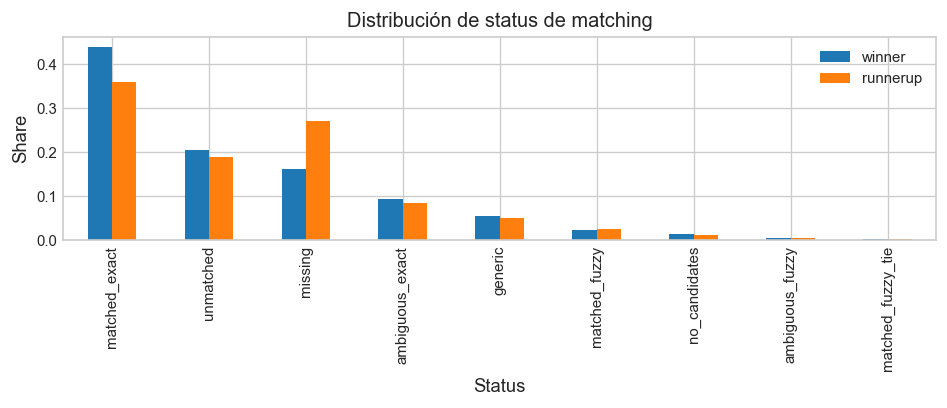

In [14]:
# Party matching audit
winner_status = df['winner_party_match_status'].value_counts(dropna=False).reset_index()
winner_status.columns = ['winner_party_match_status','n_events']
winner_status['share'] = winner_status['n_events'] / len(df)
save_table(winner_status, 'winner_party_match_status', also_md=True)
show_table(winner_status, title='Winner Party Match Status')

runner_status = df['runnerup_party_match_status'].value_counts(dropna=False).reset_index()
runner_status.columns = ['runnerup_party_match_status','n_events']
runner_status['share'] = runner_status['n_events'] / len(df)
save_table(runner_status, 'runnerup_party_match_status', also_md=True)
show_table(runner_status, title='Runner-up Party Match Status')

# EFW post-2000 missing ideology iso3 list
if 'efw_post2000' in df.columns:
    df_post = df[df['efw_post2000'] == True]
    iso3_missing_ideo = df_post[df_post['winner_ideo_vparty'].isna()].groupby('iso3').size().reset_index(name='n_events_missing_winner_ideo')
    iso3_missing_ideo = iso3_missing_ideo.sort_values('n_events_missing_winner_ideo', ascending=False)
    save_table(iso3_missing_ideo, 'efw2000_missing_ideology_iso3')
    show_table(iso3_missing_ideo.head(20), title='EFW Post-2000: Missing Winner Ideology (top 20)')

# Manual override backlog
backlog = df[(df['margin'].notna()) & (
    df['winner_party_match_status'].isin(['ambiguous_exact','ambiguous_fuzzy','matched_fuzzy_tie']) |
    df['runnerup_party_match_status'].isin(['ambiguous_exact','ambiguous_fuzzy','matched_fuzzy_tie'])
)]
backlog_tab = backlog.groupby('iso3').size().reset_index(name='n_events_backlog')
backlog_tab = backlog_tab.sort_values('n_events_backlog', ascending=False)
save_table(backlog_tab, 'party_match_backlog', also_md=True)
show_table(backlog_tab.head(20), title='Manual Override Backlog (top 20)')


# Visualización de status de matching (winner vs runner-up)
if {'winner_party_match_status','runnerup_party_match_status'}.issubset(df.columns):
    w = df['winner_party_match_status'].value_counts(normalize=True)
    r = df['runnerup_party_match_status'].value_counts(normalize=True)
    comp = pd.concat([w, r], axis=1, keys=['winner','runnerup']).fillna(0)
    comp.plot(kind='bar', figsize=(8,3.5))
    plt.title('Distribución de status de matching')
    plt.xlabel('Status')
    plt.ylabel('Share')
    plt.tight_layout()
    save_fig('party_match_status_share')
    plt.show()


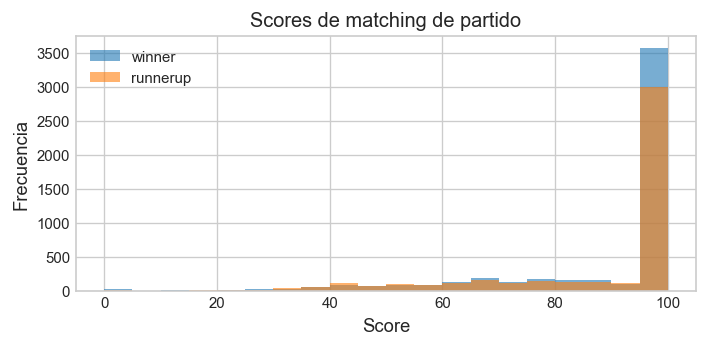

In [15]:
# Distribución de scores de matching
for col in ['winner_party_match_score','runnerup_party_match_score']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if {'winner_party_match_score','runnerup_party_match_score'}.issubset(df.columns):
    plt.figure(figsize=(6,3))
    plt.hist(df['winner_party_match_score'].dropna(), bins=20, alpha=0.6, label='winner')
    plt.hist(df['runnerup_party_match_score'].dropna(), bins=20, alpha=0.6, label='runnerup')
    plt.title('Scores de matching de partido')
    plt.xlabel('Score')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    save_fig('party_match_score_hist')
    plt.show()


## Ideología y variables derivadas

Construimos indicadores derivados de ideología (diferenciales, márgenes firmados, cercanía) y cuantificamos la disponibilidad efectiva de estas variables.

Market Margin Density


,abs_market_margin_leq,n_events,share
0,0.5,33,0.026764
1,1.0,67,0.054339
2,2.0,113,0.091646
3,5.0,248,0.201135
4,10.0,452,0.366586


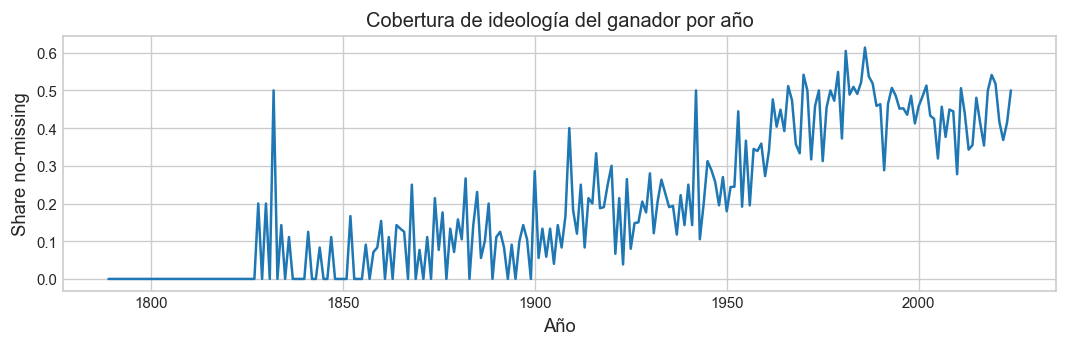

In [16]:
# Ideology audit + derived political variables

df = df.copy()

# Derived ideology variables
if {'winner_ideo_vparty','runnerup_ideo_vparty'}.issubset(df.columns):
    df['ideo_diff'] = df['winner_ideo_vparty'] - df['runnerup_ideo_vparty']
    df['market_winner'] = np.where(df['ideo_diff'].notna(), df['ideo_diff'] >= 0, np.nan)
    df['market_winner'] = df['market_winner'].astype('boolean')

    df['market_margin'] = np.where(
        df['ideo_diff'].notna() & df['margin'].notna(),
        np.where(df['ideo_diff'] >= 0, df['margin'], -df['margin']),
        np.nan
    )

    for thr in [1,2,5,10]:
        col = f'close_{thr}pp'
        df[col] = pd.Series(
            np.where(df['market_margin'].notna(), np.abs(df['market_margin']) <= thr, np.nan),
            dtype='boolean'
        )

if {'winner_ideo_ok','runnerup_ideo_ok'}.issubset(df.columns):
    df['ideo_both_ok'] = (df['winner_ideo_ok'].fillna(False) & df['runnerup_ideo_ok'].fillna(False)).astype('boolean')
else:
    df['ideo_both_ok'] = pd.Series([False]*len(df), dtype='boolean')

# RD-ready flag
if 'market_margin' in df.columns:
    df['analysis_ideo_ok'] = (df['ideo_both_ok'] & df['market_margin'].notna()).astype('boolean')

# Sanity checks
if 'market_margin' in df.columns:
    bad = df[df['market_margin'].notna() & (df['margin'].isna())]
    assert bad.empty, f"market_margin nonmissing but margin missing: {len(bad)}"

# Summary table for market_margin density
if 'market_margin' in df.columns:
    both_ideo = df[df['market_margin'].notna()]
    thresholds = [0.5,1,2,5,10]
    rows = []
    for thr in thresholds:
        rows.append({'abs_market_margin_leq': thr, 'n_events': int((both_ideo['market_margin'].abs() <= thr).sum()), 'share': float((both_ideo['market_margin'].abs() <= thr).mean())})
    density = pd.DataFrame(rows)
    save_table(density, 'market_margin_density', also_md=True)
    show_table(density, title='Market Margin Density')


# Cobertura de ideología por año
if {'election_year','winner_ideo_vparty'}.issubset(df.columns):
    ideo_year = df.groupby('election_year')['winner_ideo_vparty'].apply(lambda s: s.notna().mean()).reset_index(name='share_winner_ideo')
    save_table(ideo_year, 'ideology_coverage_by_year')

    plt.figure(figsize=(9,3))
    plt.plot(ideo_year['election_year'], ideo_year['share_winner_ideo'])
    plt.title('Cobertura de ideología del ganador por año')
    plt.xlabel('Año')
    plt.ylabel('Share no-missing')
    plt.tight_layout()
    save_fig('ideology_coverage_by_year')
    plt.show()


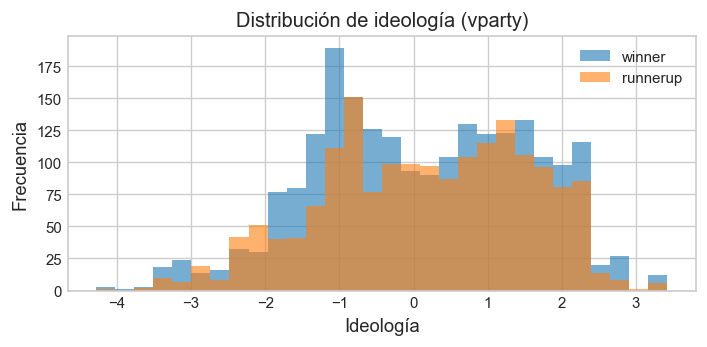

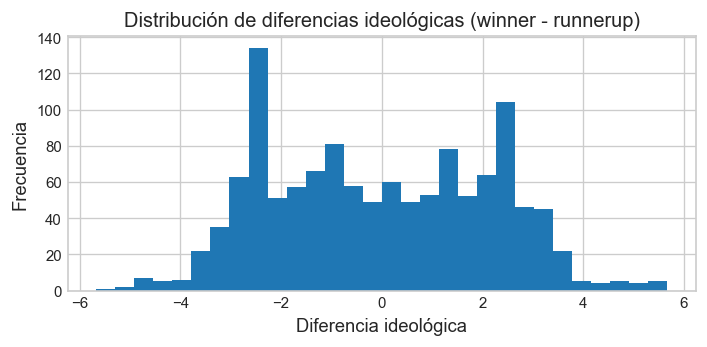

In [17]:
# Distribuciones de ideología
if {'winner_ideo_vparty','runnerup_ideo_vparty'}.issubset(df.columns):
    plt.figure(figsize=(6,3))
    plt.hist(df['winner_ideo_vparty'].dropna(), bins=30, alpha=0.6, label='winner')
    plt.hist(df['runnerup_ideo_vparty'].dropna(), bins=30, alpha=0.6, label='runnerup')
    plt.title('Distribución de ideología (vparty)')
    plt.xlabel('Ideología')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    save_fig('ideology_vparty_hist')
    plt.show()

if 'ideo_diff' in df.columns:
    plt.figure(figsize=(6,3))
    plt.hist(df['ideo_diff'].dropna(), bins=30)
    plt.title('Distribución de diferencias ideológicas (winner - runnerup)')
    plt.xlabel('Diferencia ideológica')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    save_fig('ideology_diff_hist')
    plt.show()


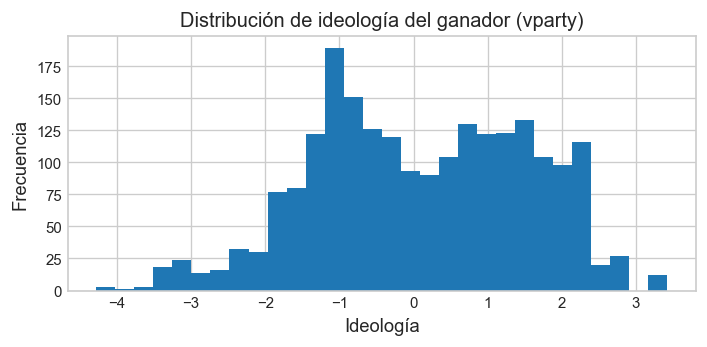

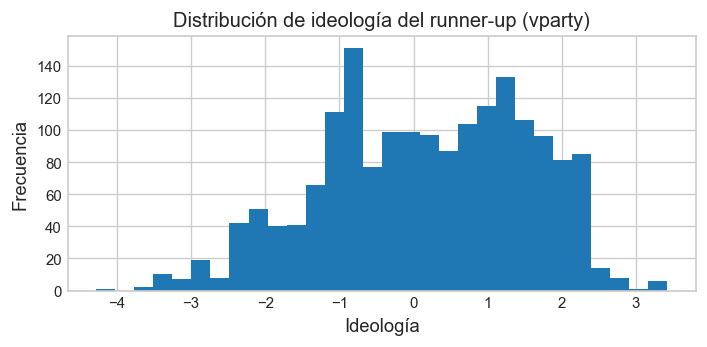

In [18]:
# Histogramas separados: ideología winner vs runner-up
if {'winner_ideo_vparty','runnerup_ideo_vparty'}.issubset(df.columns):
    # Winner
    plt.figure(figsize=(6,3))
    plt.hist(df['winner_ideo_vparty'].dropna(), bins=30)
    plt.title('Distribución de ideología del ganador (vparty)')
    plt.xlabel('Ideología')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    save_fig('ideology_winner_hist')
    plt.show()

    # Runner-up
    plt.figure(figsize=(6,3))
    plt.hist(df['runnerup_ideo_vparty'].dropna(), bins=30)
    plt.title('Distribución de ideología del runner-up (vparty)')
    plt.xlabel('Ideología')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    save_fig('ideology_runnerup_hist')
    plt.show()


## Flags institucionales

Los flags (dos rondas, plebiscitos, unopposed, indirectas, etc.) permiten segmentar la muestra por reglas institucionales. Se mide su prevalencia y su distribución por tipo de elección.

In [19]:
# Convert flag_* columns to boolean
flag_cols = [c for c in df.columns if c.startswith('flag_')]
for col in flag_cols:
    df[col] = df[col].fillna(0).astype(int).astype(bool)



Prevalencia de flags


,flag,n_true,share_true
8,flag_appointed,327,0.050284
9,flag_non_partisan,310,0.047670
0,flag_two_round,250,0.038444
4,flag_unopposed,161,0.024758
6,flag_constituent,146,0.022451
7,flag_vacant_seats,114,0.017530
3,flag_plebiscite,76,0.011687
1,flag_inconsequential,69,0.010610
5,flag_indirect,59,0.009073
2,flag_coup,42,0.006459


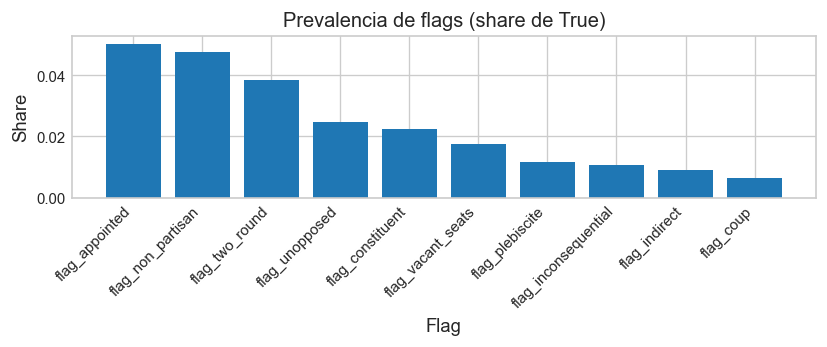

In [20]:
# Prevalencia de flags institucionales
flag_cols = [c for c in df.columns if c.startswith('flag_')]
if flag_cols:
    flag_stats = []
    for c in flag_cols:
        s = df[c].fillna(0)
        try:
            s = s.astype(int)
        except Exception:
            s = s.astype(float).fillna(0).astype(int)
        flag_stats.append({
            'flag': c,
            'n_true': int(s.sum()),
            'share_true': float(s.mean())
        })
    flag_tab = pd.DataFrame(flag_stats).sort_values('share_true', ascending=False)
    save_table(flag_tab, 'flag_prevalence', also_md=True)
    show_table(flag_tab, title='Prevalencia de flags')

    plt.figure(figsize=(7,3))
    plt.bar(flag_tab['flag'], flag_tab['share_true'])
    plt.title('Prevalencia de flags (share de True)')
    plt.xlabel('Flag')
    plt.ylabel('Share')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_fig('flag_prevalence_bar')
    plt.show()

    if 'office_type' in df.columns:
        flag_by_office = df.groupby('office_type')[flag_cols].mean(numeric_only=True)
        save_table(flag_by_office.reset_index(), 'flag_by_office_type')
